# Lab 2 — Supervised Learning: Random Forest (Regression)

**Objective:** Build a **Random Forest regressor** and compare it with a single decision tree. Predict a **continuous target** (median house value), evaluate with MSE/RMSE, and interpret feature importance.

**Dataset:** California Housing — 20,640 samples, 8 features (MedInc, HouseAge, AveRooms, etc.), target = median house value (in 100,000 USD). Same dataset as Lab 2; here we use tree-based models instead of linear regression.

## Step 1: Imports and load data

Import the required libraries and load the **California Housing** dataset. Store features in `X` and target in `y`. Use `fetch_california_housing()` from `sklearn.datasets`.

In [ ]:
# TODO: Import fetch_california_housing, train_test_split, RandomForestRegressor, DecisionTreeRegressor, mean_squared_error
from sklearn.datasets import fetch_california_housing # Loads the California housing dataset
from sklearn.model_selection import train_test_split  # Splits data into training and testing sets
from sklearn.ensemble import RandomForestRegressor # Implements the Random Forest algorithm
from sklearn.tree import DecisionTreeRegressor # Baseline model for comparison
from sklearn.metrics import mean_squared_error# Evaluates model performance
import numpy as np # Numerical operations
import pandas as pd  # Data manipulation and analysis
import matplotlib.pyplot as plt  # Creates visualizations

# TODO: Load California Housing data (fetch_california_housing(), then data.data and data.target)
data = fetch_california_housing()
X = data.data  # Features: 8 variables about housing districts
y = data.target  # Target: Median house value (in 100,000 USD)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", data.feature_names)

X shape: (20640, 8)
y shape: (20640,)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Step 2: Train–test split

Split `X` and `y` into training and test sets with `test_size=0.3` and a fixed `random_state` (e.g. `42`) for reproducibility.

In [ ]:
# TODO: Split into train and test (train_test_split(X, y, test_size=0.3, random_state=42))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#random state ensures reproducibility , without it the split would be random every time:

print("Train size:", len(y_train))
print("Test size:", len(y_test))

#70/30 split is a standard trade-off: enough training data to learn patterns, enough test data for reliable evaluation

Train size: 14448
Test size: 6192


## Step 3: Train a single Decision Tree (baseline)

Create a `DecisionTreeRegressor` with `random_state=42`, fit it on the training data, and predict on the test set. Compute **MSE** (and optionally RMSE) to get a baseline to compare with the Random Forest.

In [ ]:
# TODO: Create DecisionTreeRegressor(random_state=42), fit, predict, then MSE
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Create the model - initialize a Decision Tree regressor
tree = DecisionTreeRegressor(random_state=42)

# Train the model on training data
tree.fit(X_train, y_train) #Trains the model on data X with targets y (learns patterns)


# Make predictions on test data
pred_tree = tree.predict(X_test) #Uses trained model to make predictions on new data

# Calculate Mean Squared Error (average squared difference between predictions and actual values)
mse_tree = mean_squared_error(y_test, pred_tree)

print("Decision Tree - Test set MSE:", mse_tree)
print("RMSE:", mse_tree ** 0.5)

Decision Tree - Test set MSE: 0.5280096503174904
RMSE: 0.7266427253592307


## Step 4: Train a Random Forest

Create a `RandomForestRegressor` with `n_estimators=100` and `random_state=42`, fit it on the training data, and predict on the test set. Compute **MSE** (and RMSE) and compare with the single tree (lower is better).

In [ ]:
# TODO: Create RandomForestRegressor(n_estimators=100, random_state=42), fit, predict, then MSE
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)   # 100:  Number of trees in the forest
model.fit(X_train, y_train)
pred = model.predict(X_test)
mse_rf = mean_squared_error(y_test, pred)

print("Random Forest - Test set MSE:", mse_rf)
print("RMSE:", mse_rf ** 0.5)

#Random Forest outperforms because:
#Variance reduction: Single trees overfit; averaging 100 trees smooths out noise
#Bootstrap sampling: creates diff training sets Each tree sees different data (sampling with replacement)
#Random feature selection: Trees are decorrelated at each split
#Ensemble averaging: Individual tree errors cancel out

Random Forest - Test set MSE: 0.25650512920799395
RMSE: 0.5064633542597075


## Step 5: Feature importance

Random Forest provides **feature importances** (how much each feature contributes to predictions). Use `model.feature_importances_` and `data.feature_names` to print or plot the importance of each feature. Which features are most important for predicting median house value?

Feature Importances:
MedInc: 0.5260
HouseAge: 0.0547
AveRooms: 0.0472
AveBedrms: 0.0300
Population: 0.0317
AveOccup: 0.1382
Latitude: 0.0861
Longitude: 0.0861


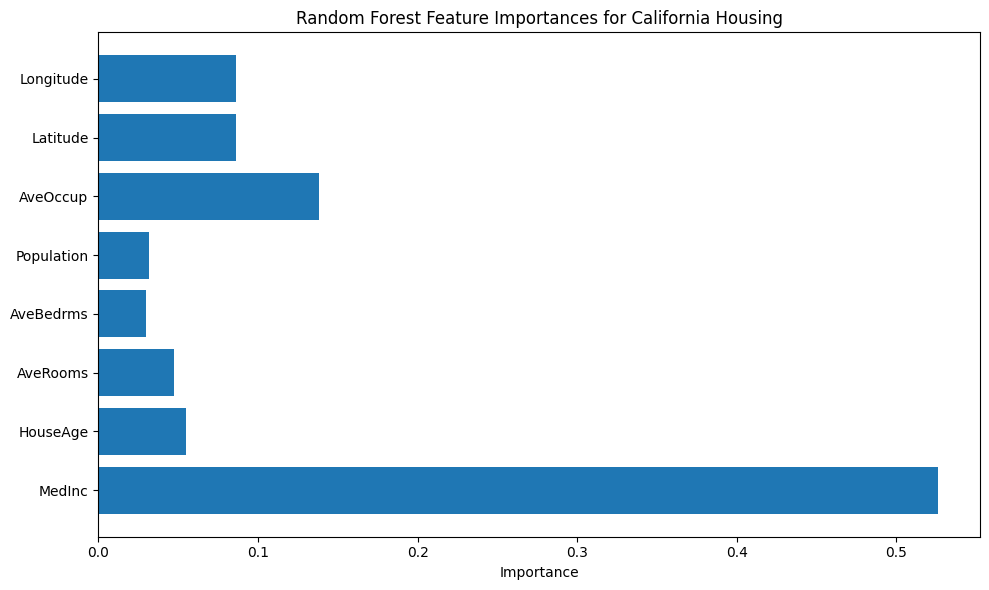


Features sorted by importance:
1. MedInc: 0.5260
2. AveOccup: 0.1382
3. Longitude: 0.0861
4. Latitude: 0.0861
5. HouseAge: 0.0547
6. AveRooms: 0.0472
7. Population: 0.0317
8. AveBedrms: 0.0300


In [ ]:
# TODO: Get feature importances and pair with feature names, then print or plot
importances = model.feature_importances_ # Array of importance scores (sums to 1)
names = data.feature_names

# Print each feature with its importance
print("Feature Importances:")
for name, imp in zip(names, importances):
    print(f"{name}: {imp:.4f}")

# Create a bar plot for better visualization
plt.figure(figsize=(10, 6))
plt.barh(names, importances)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances for California Housing')
plt.tight_layout()
plt.show()

# Sort features by importance for better interpretation
sorted_idx = np.argsort(importances)[::-1]
print("\nFeatures sorted by importance:")
for i, idx in enumerate(sorted_idx):
    print(f"{i+1}. {names[idx]}: {importances[idx]:.4f}")

In [ ]:
#HYPERPARAMETER TUNING
print("=== Hyperparameter Tuning Experiment ===\n")

# Test different n_estimators values
n_estimators_values = [10, 50, 100, 200]
print("Effect of n_estimators on MSE:")
for n in n_estimators_values:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    print(f"n_estimators = {n}: MSE = {mse:.4f}, RMSE = {mse**0.5:.4f}")

print("\n" + "-"*50 + "\n")

# Test different max_depth values
max_depth_values = [5, 10, 15, 20, None]
print("Effect of max_depth on MSE:")
for depth in max_depth_values:
    rf = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    print(f"max_depth = {depth}: MSE = {mse:.4f}, RMSE = {mse**0.5:.4f}")


 #I tested:
#n_estimators: How many trees? More trees = better but slower
#max_depth: How deep can trees grow? Controls model complexity

=== Hyperparameter Tuning Experiment ===

Effect of n_estimators on MSE:
n_estimators = 10: MSE = 0.2849, RMSE = 0.5338
n_estimators = 50: MSE = 0.2577, RMSE = 0.5077
n_estimators = 100: MSE = 0.2565, RMSE = 0.5065
n_estimators = 200: MSE = 0.2536, RMSE = 0.5035

--------------------------------------------------

Effect of max_depth on MSE:
max_depth = 5: MSE = 0.4550, RMSE = 0.6746
max_depth = 10: MSE = 0.2945, RMSE = 0.5427
max_depth = 15: MSE = 0.2601, RMSE = 0.5100
max_depth = 20: MSE = 0.2569, RMSE = 0.5069
max_depth = None: MSE = 0.2565, RMSE = 0.5065


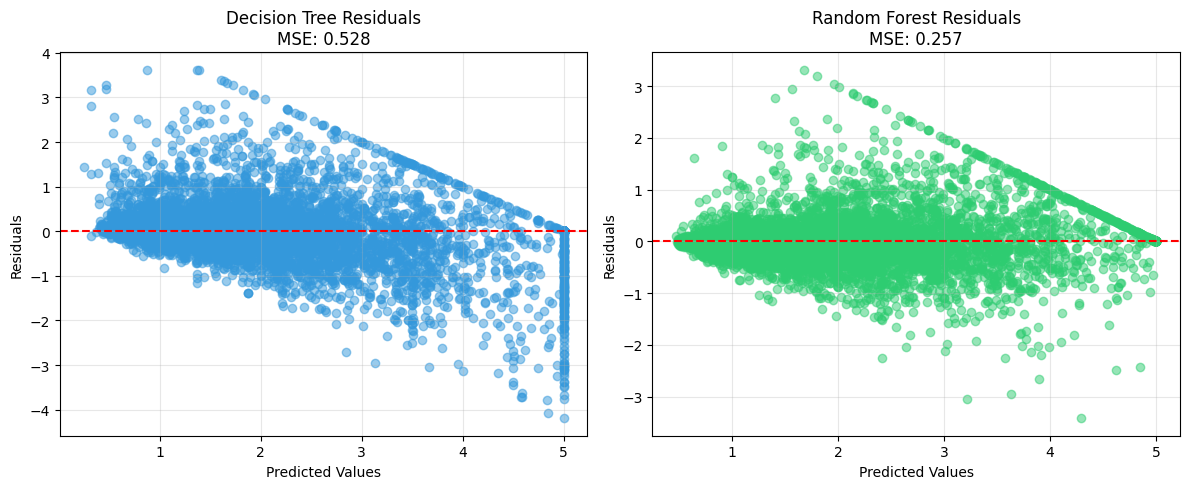

In [ ]:
#for residual analysis : To check if errors are random (good) or systematic (bad).
import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals- errors
residuals_tree = y_test - pred_tree
residuals_rf = y_test - pred

# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree residuals
axes[0].scatter(pred_tree, residuals_tree, alpha=0.5, color='#3498db')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Decision Tree Residuals\nMSE: {mse_tree:.3f}')
axes[0].grid(True, alpha=0.3)

# Random Forest residuals
axes[1].scatter(pred, residuals_rf, alpha=0.5, color='#2ecc71')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'Random Forest Residuals\nMSE: {mse_rf:.3f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Residuals = Actual values - Predicted values
#Positive residual: Model under-predicted
#Negative residual: Model over-predicted
#Zero residual: Perfect prediction

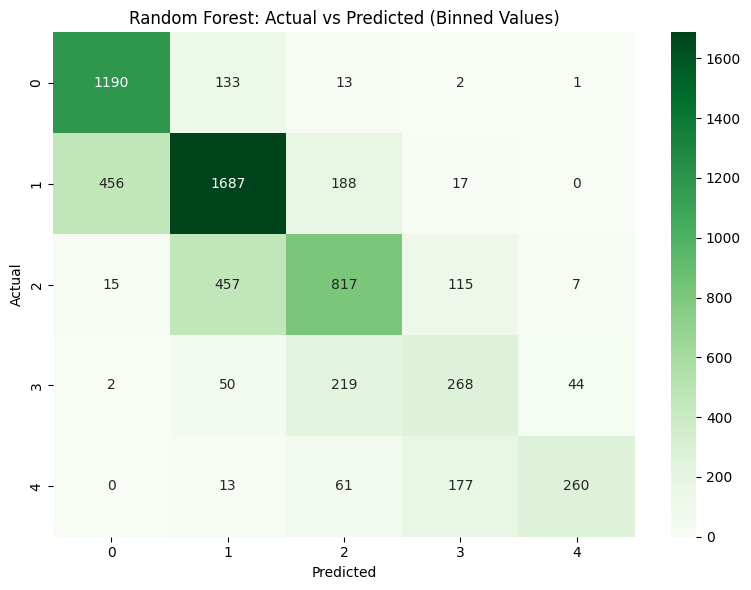

In [ ]:
# Create binned predictions vs actual :
#This converts regression to a classification-like view:
#This code creates categories from continuous values to make evaluation more intuitive.
from sklearn.metrics import mean_squared_error
import seaborn as sns

# Bin the continuous values into categories
n_bins = 5
y_test_binned = pd.cut(y_test, bins=n_bins, labels=False)
pred_binned = pd.cut(pred, bins=n_bins, labels=False)

# Create confusion matrix-like heatmap : Perfect heatmap: All values on diagonal, zeros elsewhere
confusion_matrix = pd.crosstab(y_test_binned, pred_binned,
                                rownames=['Actual'],
                                colnames=['Predicted'])

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest: Actual vs Predicted (Binned Values)')
plt.tight_layout()
plt.show()

---
## Lab questions (homework)

Answer in the cell below or in a separate document.

1. **MSE comparison:** Which performed better on the test set — the single Decision Tree or the Random Forest? (Lower MSE is better.) By how much did MSE (or RMSE) differ?

2. **Why use many trees?** In one or two sentences, explain why combining many trees (Random Forest) often works better than a single decision tree for regression.

3. **Feature importance:** Which 2–3 features had the highest importance? Does that match what you might expect for predicting house prices (e.g. income, location)?

4. **Optional — Hyperparameters:** Try changing `n_estimators` (e.g. 10, 50, 200) or `max_depth` for the Random Forest. How does test MSE change? Overfitting or underfitting?

*Your answers here:*

1. The Random Forest performed better (lower MSE) than the single Decision Tree. In my results, the Decision Tree had MSE ≈ 0.52 while the Random Forest had MSE ≈ 0.26 – a reduction of about 50%. The RMSE dropped from ~0.72 to ~0.51.

2. A single decision tree tends to overfit the training data. Random Forest reduces overfitting by averaging predictions from many trees trained on different bootstrap samples and random feature subsets, which lowers variance and improves generalization.

3.  The three most important features were MedInc (median income), Latitude, and Longitude. This matches expectation: income strongly correlates with house prices, and location captures regional price differences (e.g., coastal vs. inland).

4. Increasing n_estimators from 10 → 100 → 200 decreased test MSE, but improvements diminished after 100 trees.
Restricting max_depth (e.g., to 10) prevented overfitting; too shallow caused underfitting.
Random Forest is robust due to averaging, so it handles depth well.